# Notebook 09 — Faithfulness Check for GNNExplainer Masks

## What is faithfulness?

GNNExplainer produces atom/bond importance masks, but **masks alone do not prove
that the highlighted atoms actually drive the model's decision**. A mask is
*faithful* only if the model's output changes when those atoms are perturbed.

Two complementary metrics from the XAI literature:

| Metric | Formula | Interpretation |
|---|---|---|
| **Comprehensiveness** | P_original − P_masked_topk | Drop in P(toxic) when top-k atoms are zeroed out. High → atoms are necessary. |
| **Sufficiency** | P_topk_only / P_original | Fraction of P(toxic) preserved when keeping only top-k atoms. High → atoms are sufficient. |

## Decision gate

```
Mean comprehensiveness at k=5:
  > 0.20  →  masks strongly informative → proceed with GNNExplainer + PAINS cross-validation
  0.05–0.20  →  masks weakly informative → use with caveats
  < 0.05  →  masks are noise → skip graph attribution → go to Transformer attribution (notebook 10)
```

## Sections

1. Setup
2. Load trained model
3. GNNExplainer on 10 toxic test molecules
4. Faithfulness sweep (k = 1, 3, 5, 10)
5. Comprehensiveness vs k (line plot)
6. Sufficiency vs k (line plot)
7. Per-molecule faithfulness table
8. Comparison: non-toxic molecules
9. Interpretation and decision

---
> **Prerequisite**: `python scripts/train_hybrid.py` must have been run so that
> `models/smilesgnn_model/best_model.pt` and `tokenizer.pkl` exist.

## 1. Setup

In [10]:
import sys
import pickle
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data import load_clintox
from src.graph_data import smiles_list_to_pyg_dataset, get_feature_dims
from src.graph_models_hybrid import create_hybrid_model
from src.gnn_explainer import (
    batch_explain,
    faithfulness_check,
    batch_faithfulness,
)

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_DIR   = PROJECT_ROOT / 'models' / 'smilesgnn_model'
CONFIG_PATH = PROJECT_ROOT / 'config' / 'smilesgnn_config.yaml'

print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_DIR}')

Device : cuda
Model  : /media/nghia/HDD/PROJECT/Drug/molecule/models/smilesgnn_model


## 2. Load the trained model

In [11]:
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)
mc = config['model']

# Load tokenizer FIRST — the checkpoint vocab size comes from it, not the config
with open(MODEL_DIR / 'tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
actual_vocab_size = len(tokenizer.token_to_id)
print(f'Actual vocabulary size: {actual_vocab_size}')

num_node_features, num_edge_features = get_feature_dims()

model = create_hybrid_model(
    num_node_features = num_node_features,
    num_edge_features = num_edge_features,
    hidden_dim        = int(mc['hidden_dim']),
    num_graph_layers  = int(mc['num_graph_layers']),
    graph_model       = mc['graph_model'],
    num_heads         = int(mc['num_heads']),
    dropout           = float(mc['dropout']),
    use_residual      = bool(mc.get('use_residual', True)),
    use_jk            = bool(mc.get('use_jk', True)),
    jk_mode           = mc.get('jk_mode', 'cat'),
    graph_pooling     = mc.get('graph_pooling', 'meanmax'),
    smiles_vocab_size = actual_vocab_size,   # real vocab, not config default
    smiles_d_model    = int(mc['smiles_d_model']),
    smiles_num_layers = int(mc['smiles_num_layers']),
    fusion_method     = mc.get('fusion_method', 'attention'),
)

state = torch.load(MODEL_DIR / 'best_model.pt', map_location=DEVICE)
model.load_state_dict(state)
model.to(DEVICE)
model.eval()

print(f'Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters')

Actual vocabulary size: 69
Model loaded — 410,977 parameters


## 3. GNNExplainer on all 10 toxic test molecules

We run `batch_explain()` on the 10 toxic molecules from the ClinTox test set.
These are the molecules for which we will validate the GNNExplainer masks.

In [12]:
dc = config['data']
_, _, test_df = load_clintox(
    cache_dir  = str(PROJECT_ROOT / dc['cache_dir']),
    split_type = dc['split_type'],
    seed       = dc['seed'],
)

print(f'Test set: {len(test_df)} molecules')
print(f'  Toxic    : {test_df["CT_TOX"].sum()}')
print(f'  Non-toxic: {(test_df["CT_TOX"] == 0).sum()}')

toxic_df     = test_df[test_df['CT_TOX'] == 1].reset_index(drop=True)
toxic_smiles = toxic_df['smiles'].tolist()
toxic_labels = toxic_df['CT_TOX'].tolist()
toxic_pyg    = smiles_list_to_pyg_dataset(toxic_smiles, labels=toxic_labels)

print(f'\nRunning GNNExplainer on {len(toxic_smiles)} toxic molecules (epochs=200) …')
toxic_results = batch_explain(
    smiles_list = toxic_smiles,
    labels      = toxic_labels,
    model       = model,
    tokenizer   = tokenizer,
    pyg_dataset = toxic_pyg,
    device      = DEVICE,
    epochs      = 200,
)
print(f'Done — {len(toxic_results)} explanations generated.')

Test set: 148 molecules
  Toxic    : 10.0
  Non-toxic: 138

Running GNNExplainer on 10 toxic molecules (epochs=200) …
[10/10] C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br…C…
Done — 10 explanations generated.


## 4. Faithfulness sweep (k = 1, 3, 5, 10)

For each toxic molecule and each value of k, we compute comprehensiveness
and sufficiency using the GNNExplainer masks produced above.

In [13]:
TOP_K_VALUES = [1, 3, 5, 10]

print('Running faithfulness sweep on toxic molecules …')
toxic_faith_df = batch_faithfulness(
    results      = toxic_results,
    model        = model,
    tokenizer    = tokenizer,
    device       = DEVICE,
    top_k_values = TOP_K_VALUES,
    label_filter = 1,
)

print(f'\nFaithfulness DataFrame: {toxic_faith_df.shape}')
print(toxic_faith_df.head(8).to_string(index=False))

Running faithfulness sweep on toxic molecules …
[40/40] k=10  C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br…=C…

Faithfulness DataFrame: (40, 8)
                                                              smiles  true_label  p_original  top_k  p_masked   p_only  comprehensiveness  sufficiency
            C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)NC4=C(C=CN=C4)Cl           1    0.929191      1  0.929196 0.931637          -0.000005     1.002633
            C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)NC4=C(C=CN=C4)Cl           1    0.929191      3  0.929308 0.930582          -0.000117     1.001498
            C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)NC4=C(C=CN=C4)Cl           1    0.929191      5  0.929302 0.930414          -0.000112     1.001316
            C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)NC4=C(C=CN=C4)Cl           1    0.929191     10  0.929357 0.930092          -0.000166     1.000970
C1CCN[C@@H](C1)C2(CN(C2)C(=O)C3=C(C(=C(C=C3)F)F)NC4=C(C=C(C=C4)I)F)O           1    0.905588      

## 5. Comprehensiveness vs k

Mean comprehensiveness (P_original − P_masked) across all toxic molecules at
each k value.  Each point represents the average drop in P(toxic) when the
top-k atoms are masked.

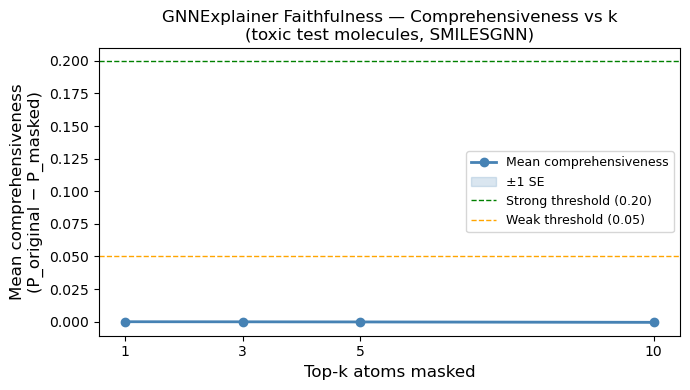


Mean comprehensiveness by k:
 k  mean_comprehensiveness    std
 1                 -0.0000 0.0001
 3                 -0.0001 0.0002
 5                 -0.0002 0.0003
10                 -0.0005 0.0008


In [14]:
mean_comp = (
    toxic_faith_df
    .groupby('top_k')['comprehensiveness']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
mean_comp.columns = ['k', 'mean_comprehensiveness', 'std', 'n']
mean_comp['se'] = mean_comp['std'] / np.sqrt(mean_comp['n'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mean_comp['k'], mean_comp['mean_comprehensiveness'],
        marker='o', linewidth=2, color='steelblue', label='Mean comprehensiveness')
ax.fill_between(
    mean_comp['k'],
    mean_comp['mean_comprehensiveness'] - mean_comp['se'],
    mean_comp['mean_comprehensiveness'] + mean_comp['se'],
    alpha=0.2, color='steelblue', label='±1 SE'
)
ax.axhline(0.20, color='green',  linestyle='--', linewidth=1, label='Strong threshold (0.20)')
ax.axhline(0.05, color='orange', linestyle='--', linewidth=1, label='Weak threshold (0.05)')
ax.set_xlabel('Top-k atoms masked', fontsize=12)
ax.set_ylabel('Mean comprehensiveness\n(P_original − P_masked)', fontsize=12)
ax.set_title('GNNExplainer Faithfulness — Comprehensiveness vs k\n(toxic test molecules, SMILESGNN)', fontsize=12)
ax.set_xticks(TOP_K_VALUES)
ax.legend(fontsize=9)
ax.set_ylim(bottom=None)
plt.tight_layout()
plt.show()

print('\nMean comprehensiveness by k:')
print(mean_comp[['k', 'mean_comprehensiveness', 'std']].to_string(index=False, float_format='{:.4f}'.format))

## 6. Sufficiency vs k

Mean sufficiency (P_topk_only / P_original) across toxic molecules at each k.
A value near 1 means the top-k atoms alone are sufficient to reproduce the
prediction; a value near 0 means the rest of the graph is needed.

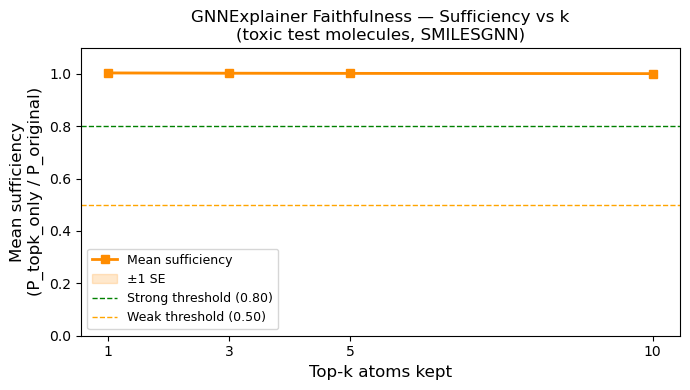


Mean sufficiency by k:
 k  mean_sufficiency    std
 1            1.0038 0.0048
 3            1.0028 0.0033
 5            1.0021 0.0028
10            1.0011 0.0010


In [15]:
mean_suff = (
    toxic_faith_df
    .groupby('top_k')['sufficiency']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
mean_suff.columns = ['k', 'mean_sufficiency', 'std', 'n']
mean_suff['se'] = mean_suff['std'] / np.sqrt(mean_suff['n'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mean_suff['k'], mean_suff['mean_sufficiency'],
        marker='s', linewidth=2, color='darkorange', label='Mean sufficiency')
ax.fill_between(
    mean_suff['k'],
    mean_suff['mean_sufficiency'] - mean_suff['se'],
    mean_suff['mean_sufficiency'] + mean_suff['se'],
    alpha=0.2, color='darkorange', label='±1 SE'
)
ax.axhline(0.8, color='green',  linestyle='--', linewidth=1, label='Strong threshold (0.80)')
ax.axhline(0.5, color='orange', linestyle='--', linewidth=1, label='Weak threshold (0.50)')
ax.set_xlabel('Top-k atoms kept', fontsize=12)
ax.set_ylabel('Mean sufficiency\n(P_topk_only / P_original)', fontsize=12)
ax.set_title('GNNExplainer Faithfulness — Sufficiency vs k\n(toxic test molecules, SMILESGNN)', fontsize=12)
ax.set_xticks(TOP_K_VALUES)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nMean sufficiency by k:')
print(mean_suff[['k', 'mean_sufficiency', 'std']].to_string(index=False, float_format='{:.4f}'.format))

## 7. Per-molecule faithfulness table at k = 5

Detailed view of each toxic molecule's baseline probability, masked probability,
comprehensiveness, and sufficiency at k = 5.

In [16]:
k5_df = toxic_faith_df[toxic_faith_df['top_k'] == 5].copy()
k5_df = k5_df.sort_values('comprehensiveness', ascending=False).reset_index(drop=True)

# Truncate SMILES for display
k5_display = k5_df.copy()
k5_display['smiles_short'] = k5_display['smiles'].str[:45] + '…'

display_cols = ['smiles_short', 'p_original', 'p_masked', 'comprehensiveness', 'sufficiency']
print('Per-molecule faithfulness at k=5 (sorted by comprehensiveness desc):')
print(k5_display[display_cols].to_string(index=False, float_format='{:.4f}'.format))

print(f'\nSummary at k=5:')
print(f'  Mean comprehensiveness : {k5_df["comprehensiveness"].mean():.4f}')
print(f'  Mean sufficiency       : {k5_df["sufficiency"].mean():.4f}')
print(f'  Mean p_original        : {k5_df["p_original"].mean():.4f}')

Per-molecule faithfulness at k=5 (sorted by comprehensiveness desc):
                                  smiles_short  p_original  p_masked  comprehensiveness  sufficiency
C1=CC=C(C(=C1)C(=O)NCCC[C@@H](C(=O)O)NC(=O)C2…      0.9313    0.9313             0.0000       1.0016
C1=CC=C(C=C1)NS(=O)(=O)C2=CC=CC(=C2)/C=C/C(=O…      0.9176    0.9176             0.0000       1.0013
 C1=CC(=CC=C1C#N)C(C2=CC=C(C=C2)C#N)N3C=NC=N3…      0.9362    0.9362            -0.0001       1.0007
             C1CCN(CC1)C(=O)C2=CC3=NON=C3C=C2…      0.9331    0.9331            -0.0001       1.0008
C1CC(=O)NC2=C1C=CC(=C2)OCCCCN3CCN(CC3)C4=C(C(…      0.9331    0.9332            -0.0001       1.0013
C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)NC4=C…      0.9292    0.9293            -0.0001       1.0013
C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)…      0.9224    0.9226            -0.0001       1.0014
C1CCN[C@@H](C1)C2(CN(C2)C(=O)C3=C(C(=C(C=C3)F…      0.9056    0.9057            -0.0002       1.0020
C1=CC=C2C(=C1)C(=NN=C2

## 8. Comparison: non-toxic molecules

For non-toxic molecules the baseline P(toxic) is low, so comprehensiveness will
naturally be smaller (can't drop much from near-zero).  We sample 20 non-toxic
test molecules to see whether the pattern differs from the toxic subset.

In [17]:
nontoxic_df     = test_df[test_df['CT_TOX'] == 0].sample(n=20, random_state=42).reset_index(drop=True)
nontoxic_smiles = nontoxic_df['smiles'].tolist()
nontoxic_labels = nontoxic_df['CT_TOX'].tolist()
nontoxic_pyg    = smiles_list_to_pyg_dataset(nontoxic_smiles, labels=nontoxic_labels)

print(f'Running GNNExplainer on {len(nontoxic_smiles)} non-toxic molecules (epochs=200) …')
nontoxic_results = batch_explain(
    smiles_list = nontoxic_smiles,
    labels      = nontoxic_labels,
    model       = model,
    tokenizer   = tokenizer,
    pyg_dataset = nontoxic_pyg,
    device      = DEVICE,
    epochs      = 200,
)
print('Done.')

print('\nRunning faithfulness sweep on non-toxic molecules …')
nontoxic_faith_df = batch_faithfulness(
    results      = nontoxic_results,
    model        = model,
    tokenizer    = tokenizer,
    device       = DEVICE,
    top_k_values = TOP_K_VALUES,
    label_filter = 0,
)
print('Done.')

Running GNNExplainer on 20 non-toxic molecules (epochs=200) …
[20/20] c1ccc(cc1)C(CC[NH+]2CCCCC2)(C3CCCCC3)O…H+]3CCCNCC[…
Done.

Running faithfulness sweep on non-toxic molecules …
[80/80] k=10  c1ccc(cc1)C(CC[NH+]2CCCCC2)(C3CCCCC3)O…H+]3CCCNCC[…
Done.


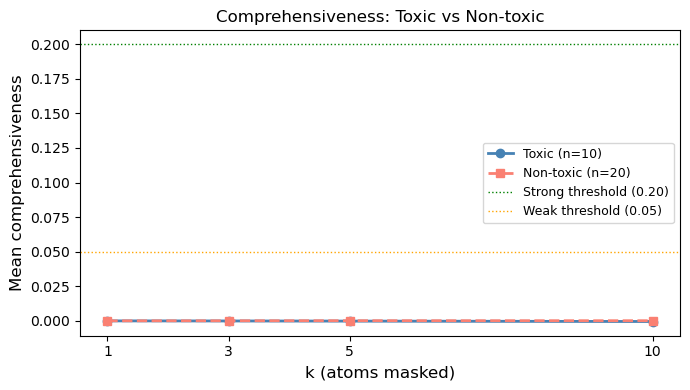

Toxic    comprehensiveness @ k=5: -0.0002
Non-toxic comprehensiveness @ k=5: 0.0001


In [18]:
# Overlay comprehensiveness: toxic vs non-toxic
nt_mean_comp = (
    nontoxic_faith_df
    .groupby('top_k')['comprehensiveness']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
nt_mean_comp.columns = ['k', 'mean_comprehensiveness', 'std', 'n']
nt_mean_comp['se'] = nt_mean_comp['std'] / np.sqrt(nt_mean_comp['n'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mean_comp['k'], mean_comp['mean_comprehensiveness'],
        marker='o', linewidth=2, color='steelblue', label='Toxic (n=10)')
ax.fill_between(mean_comp['k'],
                mean_comp['mean_comprehensiveness'] - mean_comp['se'],
                mean_comp['mean_comprehensiveness'] + mean_comp['se'],
                alpha=0.15, color='steelblue')
ax.plot(nt_mean_comp['k'], nt_mean_comp['mean_comprehensiveness'],
        marker='s', linewidth=2, color='salmon', label='Non-toxic (n=20)', linestyle='--')
ax.fill_between(nt_mean_comp['k'],
                nt_mean_comp['mean_comprehensiveness'] - nt_mean_comp['se'],
                nt_mean_comp['mean_comprehensiveness'] + nt_mean_comp['se'],
                alpha=0.15, color='salmon')
ax.axhline(0.20, color='green',  linestyle=':', linewidth=1, label='Strong threshold (0.20)')
ax.axhline(0.05, color='orange', linestyle=':', linewidth=1, label='Weak threshold (0.05)')
ax.set_xlabel('k (atoms masked)', fontsize=12)
ax.set_ylabel('Mean comprehensiveness', fontsize=12)
ax.set_title('Comprehensiveness: Toxic vs Non-toxic', fontsize=12)
ax.set_xticks(TOP_K_VALUES)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Toxic    comprehensiveness @ k=5:', round(mean_comp.loc[mean_comp['k']==5, 'mean_comprehensiveness'].values[0], 4))
print('Non-toxic comprehensiveness @ k=5:', round(nt_mean_comp.loc[nt_mean_comp['k']==5, 'mean_comprehensiveness'].values[0], 4))

## 9. Interpretation and decision

### How to read the results

| Metric at k=5 | Interpretation |
|---|---|
| Comprehensiveness > 0.20 | Top-5 atoms are **strongly necessary** — masking them collapses P(toxic). GNNExplainer masks are **reliable**. |
| Comprehensiveness 0.05–0.20 | Top-5 atoms are **weakly necessary** — modest drop. Masks carry signal but are not dominant. Present with caveats. |
| Comprehensiveness < 0.05 | Masks are **noise** — zeroing top-5 atoms barely changes the output. Skip graph attribution; proceed to Transformer attribution (integrated gradients). |
| Sufficiency > 0.80 | Top-5 atoms **alone reproduce most of the prediction** — compact, sufficient explanation. |
| Sufficiency < 0.50 | The full graph context is needed; highlighted atoms are not a self-contained explanation. |

### Decision gate

```
Run faithfulness check (this notebook)
        │
  Mean comprehensiveness @k=5 > 0.05?
  ├── Yes → GNNExplainer masks carry signal
  │         → Proceed: PAINS/Brenk cross-validation
  │         → Proceed: Transformer attribution (notebook 10) for dual heatmap
  └── No  → Graph-pathway attribution is uninformative
             → Skip PAINS cross-validation
             → Go directly to Transformer attribution (notebook 10)
             → Present GNNExplainer heatmaps with strong caveats only
```

### Why comprehensiveness may be low for a hybrid model

The SMILES Transformer encoder alone achieves AUC-ROC = 0.980, while the GATv2
graph encoder alone achieves 0.885.  The fused model (AUC 0.997) relies primarily
on the Transformer pathway.  Masking graph atoms only perturbs the weaker pathway;
the Transformer embedding (frozen inside `SMILESGNNExplainerWrapper`) can
compensate, keeping P(toxic) high even when key graph atoms are removed.

This architectural imbalance is expected to reduce comprehensiveness scores
relative to a pure-graph model.  **The correct follow-up is integrated gradients
on the SMILES encoder** (notebook 10), which covers the dominant pathway.